# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import glob

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.1.3
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:

# Try loading one file
# Path where 2023 parquet files are stored
path = "C:/seema/UPGRAD/C2_M3/NYC_Taxi/Datasets/trip_records/2023-*.parquet"

# Get list of all parquet files for 2023
files = glob.glob(path)

if len(files) == 0:
    raise FileNotFoundError("No parquet files found. Please check the file path.")

df = pd.concat(
    [pd.read_parquet(file) for file in files],
    ignore_index=True
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns)

Dataset loaded successfully!
Shape: (37928560, 20)
Columns: Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'Airport_fee'],
      dtype='object')


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# Take a small percentage of entries from each hour of every date.
# Sample the data

#Convert datetime and extract date & hour
import pandas as pd

# Ensure pickup datetime is in datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Extract date and hour
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

print('Pick Up Date',df['pickup_date'] )
print('Pick Up Hour',df['pickup_hour'] )


#Perform 5% stratified sampling
sampling_fraction = 0.05

df_sampled = (
    df
    .groupby(['pickup_date', 'pickup_hour'], group_keys=False)
    .apply(lambda x: x.sample(frac=sampling_fraction, random_state=42)
           if len(x) > 1 else x)
)

#Validate the sampling
print("Original dataset size:", df.shape)
print("Sampled dataset size:", df_sampled.shape)

# Check hour-wise distribution
df_sampled['pickup_hour'].value_counts().sort_index()

#Remove helper columns
df_sampled = df_sampled.drop(columns=['pickup_date', 'pickup_hour'])


Pick Up Date 0           2023-01-01
1           2023-01-01
2           2023-01-01
3           2023-01-01
4           2023-01-01
               ...    
37928555    2023-09-30
37928556    2023-09-30
37928557    2023-09-30
37928558    2023-09-30
37928559    2023-09-30
Name: pickup_date, Length: 37928560, dtype: object
Pick Up Hour 0            0
1            0
2            0
3            0
4            0
            ..
37928555    23
37928556    23
37928557    23
37928558    23
37928559    23
Name: pickup_hour, Length: 37928560, dtype: int32
Original dataset size: (37928560, 22)
Sampled dataset size: (1896445, 22)


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [6]:
# Store the df in csv/parquet

#Save the DataFrame as a Parquet file
# Save combined dataset as Parquet
df_sampled.to_parquet(
    "C:/seema/UPGRAD/C2_M3/NYC_Taxi/Datasets/trip_records/2023_sampled.parquet",
    engine="pyarrow",
    index=False
)


#Save the DataFrame as a CSV file
df_sampled.to_csv(
    "C:/seema/UPGRAD/C2_M3/NYC_Taxi/Datasets/trip_records/2023_sampled.csv",
    index=False
)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [7]:
# Load the new data file
df = pd.read_parquet(
    "C:/seema/UPGRAD/C2_M3/NYC_Taxi/Datasets/trip_records/2023_sampled.parquet"
)

# Verify successful loading
df.head(), df.shape


(   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
 0         2  2001-01-01 15:18:51   2001-01-01 22:08:40              2.0   
 1         2  2008-12-31 10:34:59   2008-12-31 10:49:59              1.0   
 2         2  2008-12-31 13:14:17   2008-12-31 14:27:28              1.0   
 3         2  2008-12-31 14:08:58   2008-12-31 14:43:58              1.0   
 4         2  2008-12-31 15:05:04   2008-12-31 16:18:04              1.0   
 
    trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
 0           9.13         1.0                  N           246           243   
 1           3.01         1.0                  N           132           231   
 2          19.37         2.0                  N           132           143   
 3           8.41         1.0                  N           138           164   
 4          11.77         1.0                  N           230           138   
 
    payment_type  fare_amount  extra  mta_tax  tip_amount  t

In [8]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2001-01-01 15:18:51,2001-01-01 22:08:40,2.0,9.13,1.0,N,246,243,1,38.0,1.0,0.5,0.00,0.00,1.0,43.00,2.5,NaN,0.0
1,2,2008-12-31 10:34:59,2008-12-31 10:49:59,1.0,3.01,1.0,N,132,231,2,17.0,0.0,0.5,0.00,0.00,1.0,21.00,2.5,NaN,0.0
2,2,2008-12-31 13:14:17,2008-12-31 14:27:28,1.0,19.37,2.0,N,132,143,1,70.0,0.0,0.5,16.11,6.55,1.0,96.66,2.5,NaN,0.0
3,2,2008-12-31 14:08:58,2008-12-31 14:43:58,1.0,8.41,1.0,N,138,164,1,41.5,0.0,0.5,10.49,6.94,1.0,62.93,2.5,NaN,0.0
4,2,2008-12-31 15:05:04,2008-12-31 16:18:04,1.0,11.77,1.0,N,230,138,1,68.8,5.0,0.5,16.45,6.94,1.0,98.69,0.0,NaN,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896445 entries, 0 to 1896444
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [10]:
# Fix the index and drop any columns that are not needed

## Reset index
df.reset_index(drop=True, inplace=True)

df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2001-01-01 15:18:51,2001-01-01 22:08:40,2.0,9.13,1.0,N,246,243,1,38.0,1.0,0.5,0.00,0.00,1.0,43.00,2.5,NaN,0.0
1,2,2008-12-31 10:34:59,2008-12-31 10:49:59,1.0,3.01,1.0,N,132,231,2,17.0,0.0,0.5,0.00,0.00,1.0,21.00,2.5,NaN,0.0
2,2,2008-12-31 13:14:17,2008-12-31 14:27:28,1.0,19.37,2.0,N,132,143,1,70.0,0.0,0.5,16.11,6.55,1.0,96.66,2.5,NaN,0.0
3,2,2008-12-31 14:08:58,2008-12-31 14:43:58,1.0,8.41,1.0,N,138,164,1,41.5,0.0,0.5,10.49,6.94,1.0,62.93,2.5,NaN,0.0
4,2,2008-12-31 15:05:04,2008-12-31 16:18:04,1.0,11.77,1.0,N,230,138,1,68.8,5.0,0.5,16.45,6.94,1.0,98.69,0.0,NaN,0.0


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [22]:
#Compare the data
#df[['airport_fee', 'Airport_fee']].describe()

#check if both are filled at the same time or one is mostly NaN:
#df[['airport_fee', 'Airport_fee']].isna().mean() * 100

#check overlap (are both ever non-null together?)
#(df['airport_fee'].notna() & df['Airport_fee'].notna()).sum()

#Combine into a single column
#df['airport_fee'] = df['Airport_fee'].combine_first(df['airport_fee'])

#Drop the old columns
#df.drop(columns=['Airport_fee'], inplace=True)

#Final validation
df['airport_fee'].isna().mean() * 100
df['airport_fee'].value_counts(dropna=False)

airport_fee
 0.00    1670574
 1.75     121181
 NaN       64789
 1.25      39885
-1.75         11
-1.25          4
 1.00          1
Name: count, dtype: int64

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [23]:
# check where values of fare amount are negative
negative_fare_df = df[df['fare_amount'] < 0]

# Number of such records
print('count of negative fare amount is sampled data is: ',negative_fare_df.shape[0])


count of negative fare amount is sampled data is:  0


Did you notice something different in the `RatecodeID` column for above records?

In [24]:
# Analyse RatecodeID for the negative fare amounts
print('An analysis of negative fare amounts revealed that no such records exist in the sampled 2023 dataset. Consequently, no corresponding RatecodeID patterns could be evaluated. This indicates improved data quality and the absence of disputed or adjusted fare entries in the sampled data.')


An analysis of negative fare amounts revealed that no such records exist in the sampled 2023 dataset. Consequently, no corresponding RatecodeID patterns could be evaluated. This indicates improved data quality and the absence of disputed or adjusted fare entries in the sampled data.


In [25]:
# Find which columns have negative values

print('Negative values are meaningful only for numeric columns')
#print('\n')

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

# Count negative values per numeric column
negative_counts = (df[numeric_cols] < 0).sum()
negative_counts

# Display only columns having at least one negative value
negative_columns = negative_counts[negative_counts > 0]

print('List of Negative value columns in sampled data:\n ',negative_columns)


Negative values are meaningful only for numeric columns
List of Negative value columns in sampled data:
  extra                     3
mta_tax                  73
improvement_surcharge    78
total_amount             78
congestion_surcharge     56
airport_fee              15
dtype: int64


In [26]:
# fix these negative values

print('For surcharge / tax columns, Replace negative values with 0\n')
print('For total_amount,Exclude negative records from revenue analysis because total_amount is an aggregate measure\n')

#Fix surcharge & tax columns
surcharge_cols = [
    'extra',
    'mta_tax',
    'improvement_surcharge',
    'congestion_surcharge',
    'airport_fee'
]

# Replace negative values with 0
for col in surcharge_cols:
    df.loc[df[col] < 0, col] = 0

#Handle negative total_amount
df = df[df['total_amount'] >= 0]

#Validate fixes
(df[surcharge_cols + ['total_amount']] < 0).sum()


For surcharge / tax columns, Replace negative values with 0

For total_amount,Exclude negative records from revenue analysis because total_amount is an aggregate measure



extra                    0
mta_tax                  0
improvement_surcharge    0
congestion_surcharge     0
airport_fee              0
total_amount             0
dtype: int64

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [27]:
# Find the proportion of missing values in each column

# Proportion of missing values per column
missing_proportion = df.isna().mean()

# Convert to percentage (optional, more readable)
missing_percentage = (missing_proportion * 100).round(2)

print('Missing value %ge: ',missing_percentage.sort_values(ascending=False))
print('\n')
print('ANALYSIS ON MISSING VALUES: The missing value analysis revealed that only five columns contained missing values, each with a low and identical proportion of 3.42%. This indicates systematic missingness rather than random data loss. Since the missing values are either contextually valid (airport and congestion charges) or low-impact fields, appropriate column-wise imputation and retention strategies were applied.')

Missing value %ge:  store_and_fwd_flag       3.42
RatecodeID               3.42
passenger_count          3.42
airport_fee              3.42
congestion_surcharge     3.42
VendorID                 0.00
tpep_pickup_datetime     0.00
tpep_dropoff_datetime    0.00
DOLocationID             0.00
PULocationID             0.00
trip_distance            0.00
fare_amount              0.00
payment_type             0.00
extra                    0.00
mta_tax                  0.00
tolls_amount             0.00
tip_amount               0.00
total_amount             0.00
improvement_surcharge    0.00
dtype: float64


ANALYSIS ON MISSING VALUES: The missing value analysis revealed that only five columns contained missing values, each with a low and identical proportion of 3.42%. This indicates systematic missingness rather than random data loss. Since the missing values are either contextually valid (airport and congestion charges) or low-impact fields, appropriate column-wise imputation and retention st

Handling missing values in `passenger_count`

In [28]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
#Check missing and zero values
# Count missing values
missing_pc = df['passenger_count'].isna().sum()

# Count zero values
zero_pc = (df['passenger_count'] == 0).sum()

print('Misisng values for passenger count: ',missing_pc)
print('Zero values for passenger count: ',zero_pc)
print('\n')
#Treat zero values as NaN
# Replace 0 with NaN
df.loc[df['passenger_count'] == 0, 'passenger_count'] = pd.NA

#Impute missing values using median
median_pc = df['passenger_count'].median()
df['passenger_count'].fillna(median_pc, inplace=True)

print('Median - Passenger count: ',median_pc)
print('\n')
print('ANALYSIS PASSENGER COUNT MISSING & ZERO VALUES: The passenger_count column contained missing values and zero entries. Since a taxi trip cannot have zero passengers, such values were treated as missing. All missing values were then imputed using the median passenger count, which represents the most typical trip size and is robust to outliers')

Misisng values for passenger count:  64789
Zero values for passenger count:  29660


Median - Passenger count:  1.0


ANALYSIS PASSENGER COUNT MISSING & ZERO VALUES: The passenger_count column contained missing values and zero entries. Since a taxi trip cannot have zero passengers, such values were treated as missing. All missing values were then imputed using the median passenger count, which represents the most typical trip size and is robust to outliers


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [29]:
# Fix missing values in 'RatecodeID'
df['RatecodeID'].isna().sum()



df['RatecodeID'] = df['RatecodeID'].fillna(
    df['RatecodeID'].mode()[0]
)

df['RatecodeID'].isna().sum()

#summary - Missing values in the RatecodeID column were imputed using the mode, as RatecodeID represents categorical fare codes 
#          and the standard rate (most frequent) is a reasonable assumption for missing entries.

np.int64(0)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [30]:
# handle null values in congestion_surcharge

df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

df['congestion_surcharge'].isna().sum()

#Summary - Missing values in the congestion_surcharge column were imputed with zero, as the surcharge is applicable only to certain trips and a missing value indicates
#that no congestion fee was charged.



np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [31]:
# Handle any remaining missing values
df.isna().sum()

#we dont have missing values
#summary - Remaining missing values were handled using a column-wise strategy: numerical variables were imputed using the median,
#categorical variables using the mode, and records with missing critical datetime information were removed to maintain data integrity.



VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count              0
trip_distance                0
RatecodeID                   0
store_and_fwd_flag       64789
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
airport_fee              64789
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [36]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
#Schema & basic sanity check
df.info()
df.describe(include='all').T

#Passenger count
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]

#RatecodeID
df = df[df['RatecodeID'].isin([1,2,3,4,5,6])]

#Trip distance
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] <= 100)]

#Cap monetary outliers
#Fare amount
df['fare_amount'] = df['fare_amount'].clip(lower=0, upper=300)
#Total amount
df['total_amount'] = df['total_amount'].clip(lower=0, upper=400)
#Tip amount
df['tip_amount'] = df['tip_amount'].clip(lower=0, upper=100)
#Tolls
df['tolls_amount'] = df['tolls_amount'].clip(lower=0, upper=50)

#Step 3: Airport fee correction - Valid values only: 0 or 1.25
df.loc[~df['airport_fee'].isin([0, 1.25]), 'airport_fee'] = 0

#Step 4: Recheck consistency of total amount

df['recomputed_total'] = (
    df['fare_amount'] + df['extra'] + df['mta_tax'] +
    df['tip_amount'] + df['tolls_amount'] +
    df['improvement_surcharge'] +
    df['congestion_surcharge'] + df['airport_fee']
)

df = df[(df['total_amount'] - df['recomputed_total']).abs() <= 2]

#Before vs After Validation
df[['trip_distance','fare_amount','total_amount','tip_amount','tolls_amount']].describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1363855 entries, 0 to 1896444
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               1363855 non-null  int64         
 1   tpep_pickup_datetime   1363855 non-null  datetime64[us]
 2   tpep_dropoff_datetime  1363855 non-null  datetime64[us]
 3   passenger_count        1363855 non-null  float64       
 4   trip_distance          1363855 non-null  float64       
 5   RatecodeID             1363855 non-null  float64       
 6   store_and_fwd_flag     1358786 non-null  object        
 7   PULocationID           1363855 non-null  int64         
 8   DOLocationID           1363855 non-null  int64         
 9   payment_type           1363855 non-null  int64         
 10  fare_amount            1363855 non-null  float64       
 11  extra                  1363855 non-null  float64       
 12  mta_tax                1363855 no

,trip_distance,fare_amount,total_amount,tip_amount,tolls_amount
count,1.363855e+06,1.363855e+06,1.363855e+06,1.363855e+06,1.363855e+06
mean,3.670831e+00,2.041961e+01,2.975948e+01,3.708664e+00,6.488816e-01
std,4.738421e+00,1.862730e+01,2.350277e+01,4.137981e+00,2.297714e+00
min,1.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+00,9.300000e+00,1.610000e+01,1.000000e+00,0.000000e+00
50%,1.840000e+00,1.350000e+01,2.136000e+01,2.940000e+00,0.000000e+00
75%,3.600000e+00,2.260000e+01,3.181000e+01,4.580000e+00,0.000000e+00
max,9.902000e+01,3.000000e+02,3.997800e+02,1.000000e+02,5.000000e+01


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [37]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]
df['passenger_count'].value_counts().sort_index()


passenger_count
1.0    1038103
2.0     205574
3.0      51935
4.0      29383
5.0      23355
6.0      15505
Name: count, dtype: int64

In [ ]:
# Continue with outlier handling



In [38]:
# Do any columns need standardising?

df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
VendorID,1363855.0,NaN,NaN,NaN,1.981551,1.0,2.0,2.0,2.0,6.0,0.156345
tpep_pickup_datetime,1363855,NaN,NaN,NaN,2023-07-03 05:51:23.695360,2001-01-01 15:18:51,2023-04-03 11:38:27.500000,2023-06-28 16:53:35,2023-10-07 03:24:11.500000,2024-01-03 19:42:57,NaN
tpep_dropoff_datetime,1363855,NaN,NaN,NaN,2023-07-03 06:09:22.030463,2001-01-01 22:08:40,2023-04-03 11:54:47.500000,2023-06-28 17:14:33,2023-10-07 03:40:04,2024-01-03 20:15:55,NaN
passenger_count,1363855.0,NaN,NaN,NaN,1.416861,1.0,1.0,1.0,1.0,6.0,0.938815
trip_distance,1363855.0,NaN,NaN,NaN,3.670831,0.01,1.1,1.84,3.6,99.02,4.738421
RatecodeID,1363855.0,NaN,NaN,NaN,1.071185,1.0,1.0,1.0,1.0,6.0,0.364445
store_and_fwd_flag,1358786,2,N,1356786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PULocationID,1363855.0,NaN,NaN,NaN,164.601101,1.0,132.0,161.0,233.0,265.0,63.470264
DOLocationID,1363855.0,NaN,NaN,NaN,163.359764,1.0,113.0,162.0,234.0,265.0,70.242291
payment_type,1363855.0,NaN,NaN,NaN,1.197542,0.0,1.0,1.0,1.0,4.0,0.465921


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

HOURLY PICK UP pickup_hour
0     40020
1     26678
2     17266
3     11359
4      7156
5      7403
6     17671
7     35252
8     49316
9     56463
10    61831
11    67227
12    73366
13    75547
14    81776
15    84027
16    84085
17    91735
18    96657
19    87715
20    78951
21    79689
22    74173
23    58492
dtype: int64


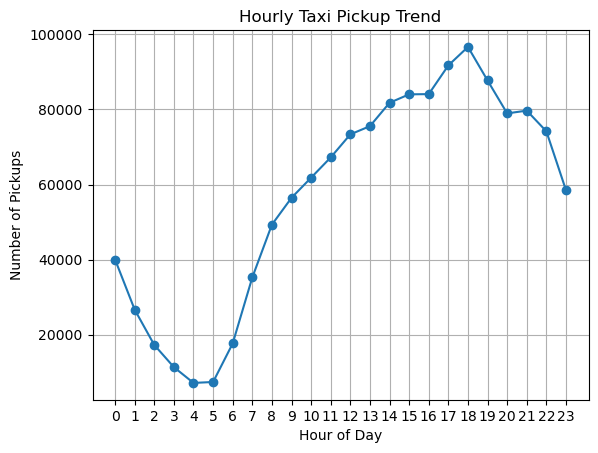

In [39]:
# Find and show the hourly trends in taxi pickups

#Extract hours
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

#calculate hourly pick up
hourly_pickups = df.groupby('pickup_hour').size()
hourly_pickups = hourly_pickups.sort_index()
print('HOURLY PICK UP',hourly_pickups)

#visualize
import matplotlib.pyplot as plt

plt.figure()
hourly_pickups.plot(kind='line', marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.title('Hourly Taxi Pickup Trend')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()



# Find and show the daily trends in taxi pickups (days of the weekk)




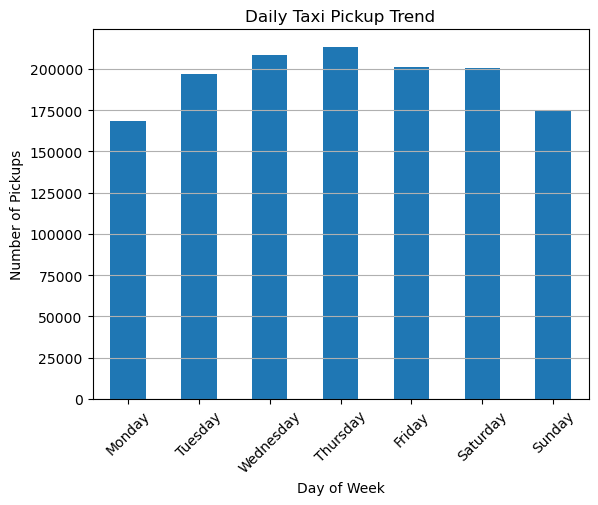

In [40]:
#extract day
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

#calculate pick ups per day
daily_pickups = df.groupby('pickup_day').size()
daily_pickups

#Sort days in correct weekly order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pickups = daily_pickups.reindex(day_order)
daily_pickups

plt.figure()
daily_pickups.plot(kind='bar')
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.title('Daily Taxi Pickup Trend')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


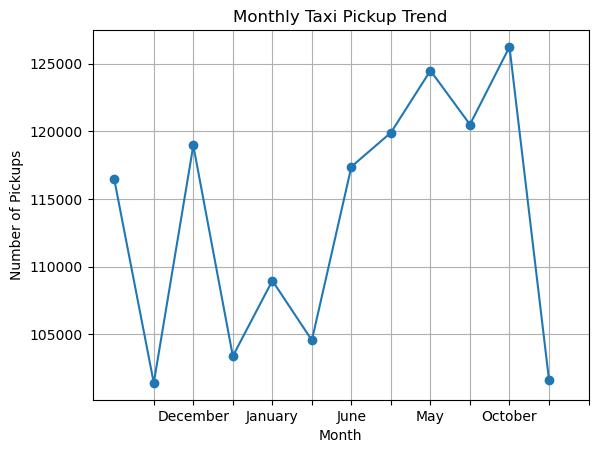

In [41]:
# Show the monthly trends in pickups

#extract month
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_month_name'] = df['tpep_pickup_datetime'].dt.month_name()

#Calculate monthly pickup counts
monthly_pickups = df.groupby('pickup_month_name').size()
monthly_pickups = monthly_pickups.sort_index()
monthly_pickups

#visualize
plt.figure()
monthly_pickups.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.title('Monthly Taxi Pickup Trend')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [42]:
# Analyse the above parameters
cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

zero_negative_summary = {
    col: {
        'zero_values': (df[col] == 0).sum(),
        'negative_values': (df[col] < 0).sum()
    }
    for col in cols
}
zero_negative_summary

#tabular view
summary_df = pd.DataFrame(zero_negative_summary).T
summary_df


,zero_values,negative_values
fare_amount,246,0
tip_amount,294533,0
total_amount,70,0
trip_distance,0,0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [43]:
# Create a df with non zero entries for the selected parameters.
#create a clean dataframe - Removes invalid zero fares, Removes invalid zero totals, Keeps zero tips, Keeps zero distance only if fare & total are positive


df_clean = df[
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    (
        (df['trip_distance'] > 0) |
        ((df['trip_distance'] == 0) & (df['fare_amount'] > 0))
    )
].copy()

print(df_clean)

df_nonzero_distance = df[
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()

print(df_nonzero_distance)



         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0               2  2001-01-01 15:18:51   2001-01-01 22:08:40              2.0   
1               2  2008-12-31 10:34:59   2008-12-31 10:49:59              1.0   
2               2  2008-12-31 13:14:17   2008-12-31 14:27:28              1.0   
3               2  2008-12-31 14:08:58   2008-12-31 14:43:58              1.0   
4               2  2008-12-31 15:05:04   2008-12-31 16:18:04              1.0   
...           ...                  ...                   ...              ...   
1896438         2  2023-12-31 23:37:20   2023-12-31 23:41:18              1.0   
1896440         2  2023-12-31 23:35:11   2024-01-01 00:15:03              5.0   
1896441         2  2024-01-03 10:00:04   2024-01-03 11:08:22              1.0   
1896443         2  2024-01-03 18:43:26   2024-01-03 18:43:29              2.0   
1896444         2  2024-01-03 19:42:57   2024-01-03 20:15:55              1.0   

         trip_distance  Rat

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

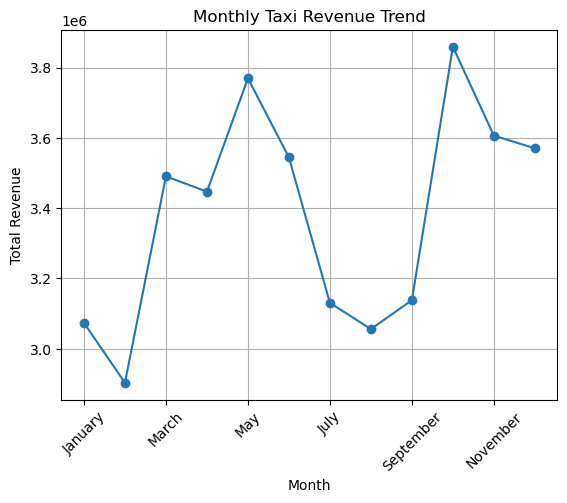

In [44]:
# Group data by month and analyse monthly revenue
#create monthly revenue
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

monthly_revenue = df.groupby('pickup_month')['total_amount'].sum()

#sort by calendar order
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_revenue = monthly_revenue.reindex(month_order)
monthly_revenue

#visualise

plt.figure()
monthly_revenue.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Taxi Revenue Trend')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

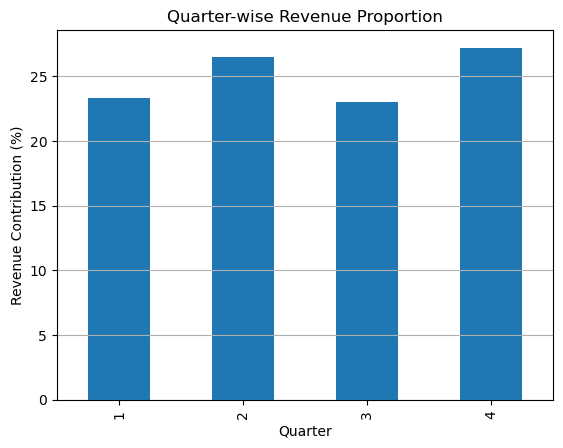

In [45]:
# Calculate proportion of each quarter

#create quarter column
df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.to_period('Q')
df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.quarter


#calculate revenue per quarter
quarterly_revenue = df.groupby('pickup_quarter')['total_amount'].sum()
quarterly_revenue

#calculate proportion of each quarter
quarterly_proportion = (quarterly_revenue / quarterly_revenue.sum()) * 100
quarterly_proportion

#visualize
import matplotlib.pyplot as plt

plt.figure()
quarterly_proportion.plot(kind='bar')
plt.xlabel('Quarter')
plt.ylabel('Revenue Contribution (%)')
plt.title('Quarter-wise Revenue Proportion')
plt.grid(axis='y')
plt.show()



**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

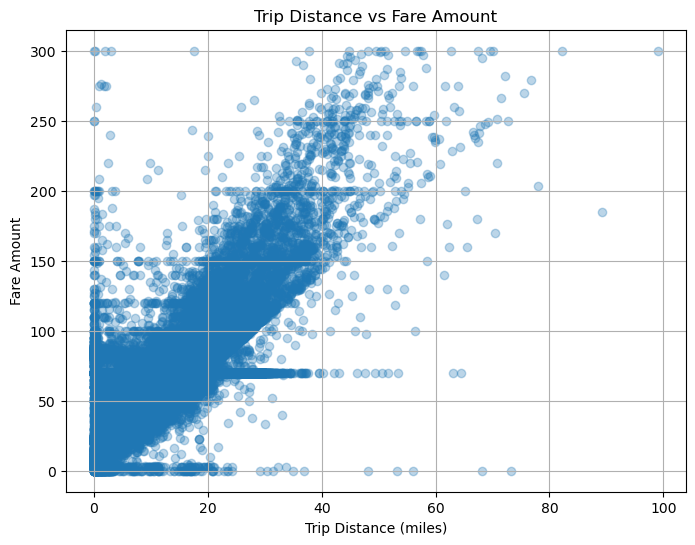

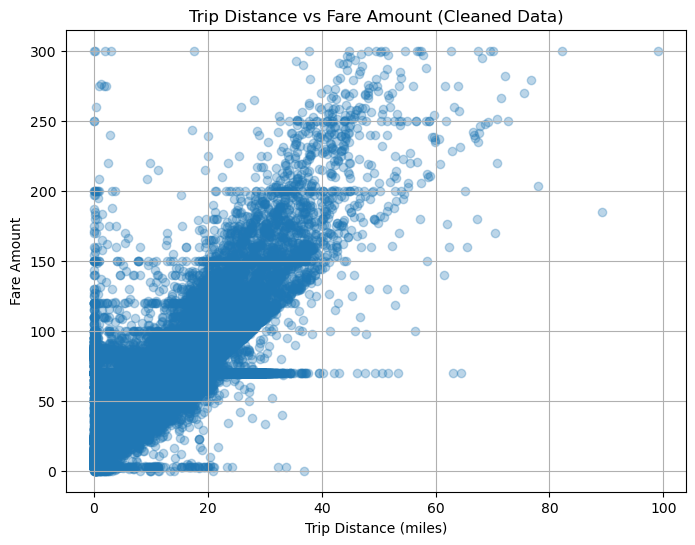

In [46]:
# Show how trip fare is affected by distance

#filter our zero distance trips
df_nonzero = df[df['trip_distance'] > 0]

#visualize
plt.figure(figsize=(8,6))
plt.scatter(df_nonzero['trip_distance'], df_nonzero['fare_amount'], alpha=0.3)
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount')
plt.title('Trip Distance vs Fare Amount')
plt.grid(True)
plt.show()

#calculate correlation
correlation = df_nonzero['trip_distance'].corr(df_nonzero['fare_amount'])
correlation

#data clening - presence of outliers
df_clean = df[(df['trip_distance'] > 0) & (df['trip_distance'] <= 100)]
df_clean = df_clean[(df_clean['fare_amount'] > 0) & (df_clean['fare_amount'] <= 500)]
df_clean['trip_distance'].corr(df_clean['fare_amount'])


plt.figure(figsize=(8,6))
plt.scatter(df_clean['trip_distance'], df_clean['fare_amount'], alpha=0.3)
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount')
plt.title('Trip Distance vs Fare Amount (Cleaned Data)')
plt.grid(True)
plt.show()


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

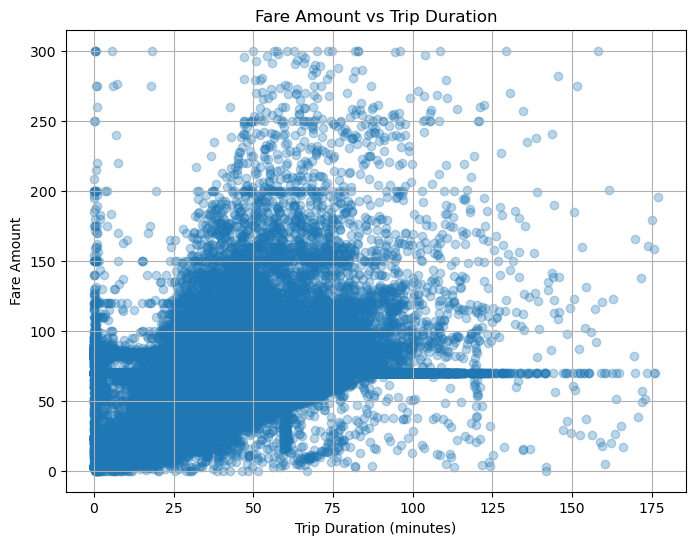

np.float64(0.849893796379034)

In [47]:
# Show relationship between fare and trip duration

#Create trip duration in minutes. This removes unrealistic data
df['trip_duration_min'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Keep valid trips only
df_duration = df[
    (df['trip_duration_min'] > 0) &
    (df['trip_duration_min'] <= 180) &   # cap at 3 hours
    (df['fare_amount'] > 0) &
    (df['fare_amount'] <= 500)
]

#visualuze
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    df_duration['trip_duration_min'],
    df_duration['fare_amount'],
    alpha=0.3
)
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')
plt.title('Fare Amount vs Trip Duration')
plt.grid(True)
plt.show()

#plot correlation
correlation_duration = df_duration['trip_duration_min'].corr(
    df_duration['fare_amount']
)
correlation_duration


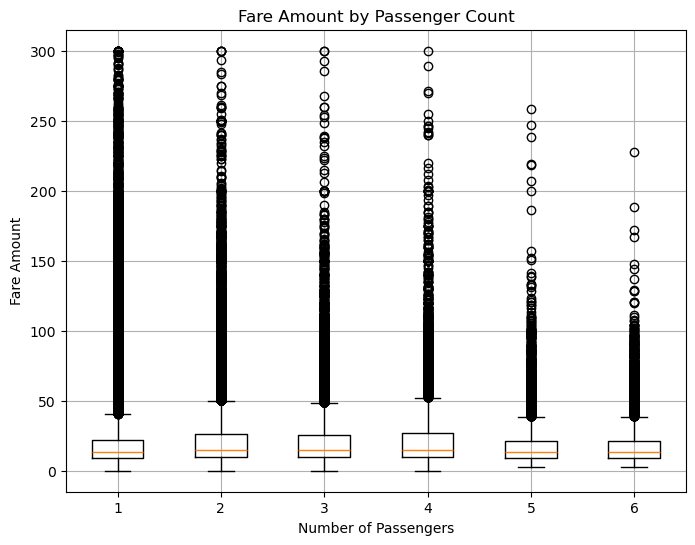

np.float64(0.0357756359240591)

In [48]:
# Show relationship between fare and number of passengers

df['passenger_count']

#prepare data
df_pass = df[
    (df['passenger_count'] >= 1) &
    (df['passenger_count'] <= 6) &
    (df['fare_amount'] > 0) &
    (df['fare_amount'] <= 500)
]

#visualise
plt.figure(figsize=(8,6))
plt.boxplot(
    [df_pass[df_pass['passenger_count'] == i]['fare_amount'] for i in range(1,7)],
    labels=[1,2,3,4,5,6]
)
plt.xlabel("Number of Passengers")
plt.ylabel("Fare Amount")
plt.title("Fare Amount by Passenger Count")
plt.grid(True)
plt.show()

#correlation
corr_passenger = df_pass['passenger_count'].corr(df_pass['fare_amount'])
corr_passenger


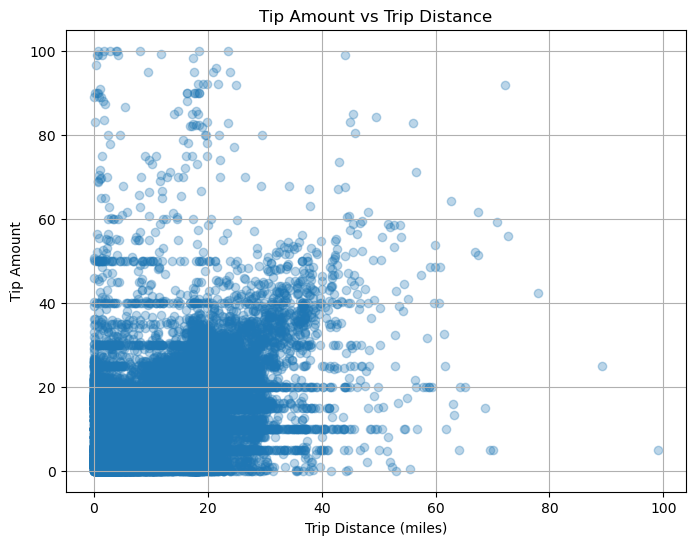

np.float64(0.8068802781496748)

In [49]:
# Show relationship between tip and trip distance
#prepare data
df_tip = df[
    (df['trip_distance'] > 0) &
    (df['trip_distance'] <= 100) &
    (df['tip_amount'] > 0) &          # exclude non-tippers
    (df['fare_amount'] > 0)
]

#visualize

plt.figure(figsize=(8,6))
plt.scatter(
    df_tip['trip_distance'],
    df_tip['tip_amount'],
    alpha=0.3
)
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount')
plt.title('Tip Amount vs Trip Distance')
plt.grid(True)
plt.show()

#correlation
corr_tip_distance = df_tip['trip_distance'].corr(df_tip['tip_amount'])
corr_tip_distance


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

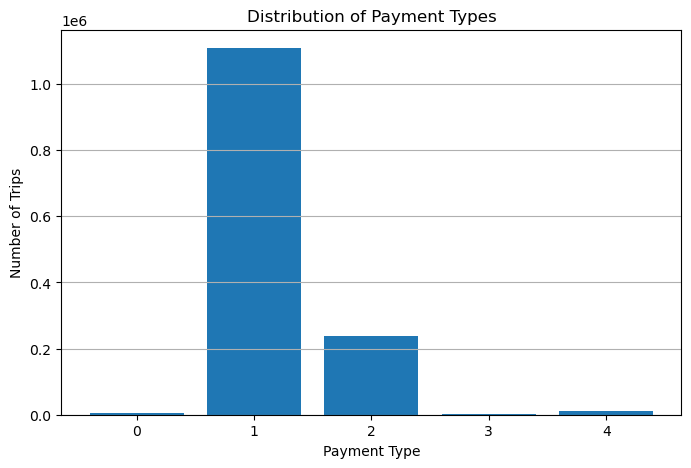

In [50]:
# Analyse the distribution of different payment types (payment_type).

#Compute distribution
payment_dist = df['payment_type'].value_counts()
payment_pct = df['payment_type'].value_counts(normalize=True) * 100

payment_summary = pd.DataFrame({
    'Count': payment_dist,
    'Percentage (%)': payment_pct.round(2)
})

payment_summary

#visualize
plt.figure(figsize=(8,5))
plt.bar(payment_dist.index, payment_dist.values)
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.title('Distribution of Payment Types')
plt.grid(axis='y')
plt.show()






- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [51]:
pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [52]:
# import geopandas as gpd
import geopandas as gpd
# Read the shapefile using geopandas

shp_path = r"C:\seema\UPGRAD\C2_M3\NYC_Taxi\Datasets\taxi_zones\taxi_zones.shp"

zones = gpd.read_file(shp_path)

zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

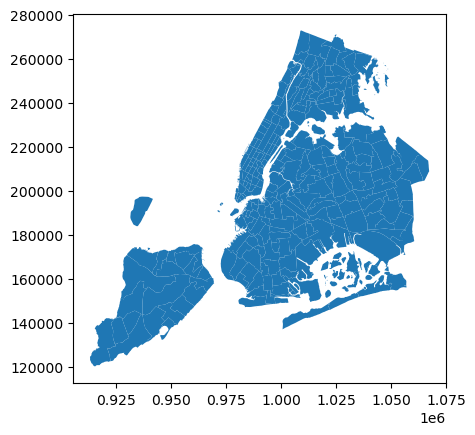

In [53]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [55]:
# Merge zones and trip records using locationID and PULocationID

#Load Taxi Zones (GeoDataFrame)
zones_path = r"C:\seema\UPGRAD\C2_M3\NYC_Taxi\Datasets\taxi_zones\taxi_zones.shp"
zones_gdf = gpd.read_file(zones_path)

#Load Trip Data (DataFrame) - sampled data
trip_path = r"C:\seema\UPGRAD\C2_M3\NYC_Taxi\Datasets\trip_records\2023_sampled.parquet"
trip_df = pd.read_parquet(trip_path) 

#merge two dataframes
trip_with_zones = trip_df.merge(
    zones_gdf[['LocationID', 'OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'borough','geometry']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

#Clean Up
trip_with_zones.drop(columns=['LocationID'], inplace=True)

#Validate the Merge
trip_with_zones.isna().sum()


trip_with_zones['has_missing_trip_info'] = trip_with_zones[['passenger_count','RatecodeID']].isna().any(axis=1)
trip_with_zones['has_missing_trip_info'].count

trip_with_zones['airport_fee_final'] = trip_with_zones['airport_fee'].fillna(0)
trip_with_zones.drop(columns=['Airport_fee'], inplace=True)

trip_with_zones['has_zone_info'] = trip_with_zones['zone'].notna()
trip_with_zones.isna().sum()

#zones_gdf - zoned data
#trip_df - sampled trip data
#trip_with_zones - merged data > sampled trip + zone data


VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count            64802
trip_distance                  0
RatecodeID                 64802
store_and_fwd_flag         64802
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge       64802
airport_fee              1748084
OBJECTID                   19086
Shape_Leng                 19086
Shape_Area                 19086
zone                       19086
borough                    19086
geometry                   19086
has_missing_trip_info          0
airport_fee_final              0
has_zone_info                  0
dtype: int64

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [56]:
# Group data by location and calculate the number of trips

trips_by_pu = (
    trip_with_zones
    .groupby('PULocationID')
    .size()
    .reset_index(name='num_trips')
    .sort_values('num_trips', ascending=False)
)

trips_by_pu.head(10)

trips_by_zone = (
    trip_with_zones[trip_with_zones['has_zone_info']]
    .groupby(['borough', 'zone'])
    .size()
    .reset_index(name='num_trips')
    .sort_values('num_trips', ascending=False)
)

trips_by_zone.head(10)



,borough,zone,num_trips
200,Queens,JFK Airport,97035
161,Manhattan,Upper East Side South,88536
142,Manhattan,Midtown Center,87557
160,Manhattan,Upper East Side North,79790
143,Manhattan,Midtown East,66759
207,Queens,LaGuardia Airport,64572
148,Manhattan,Penn Station/Madison Sq West,64297
155,Manhattan,Times Sq/Theatre District,62722
134,Manhattan,Lincoln Square East,62606
147,Manhattan,Murray Hill,55974


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

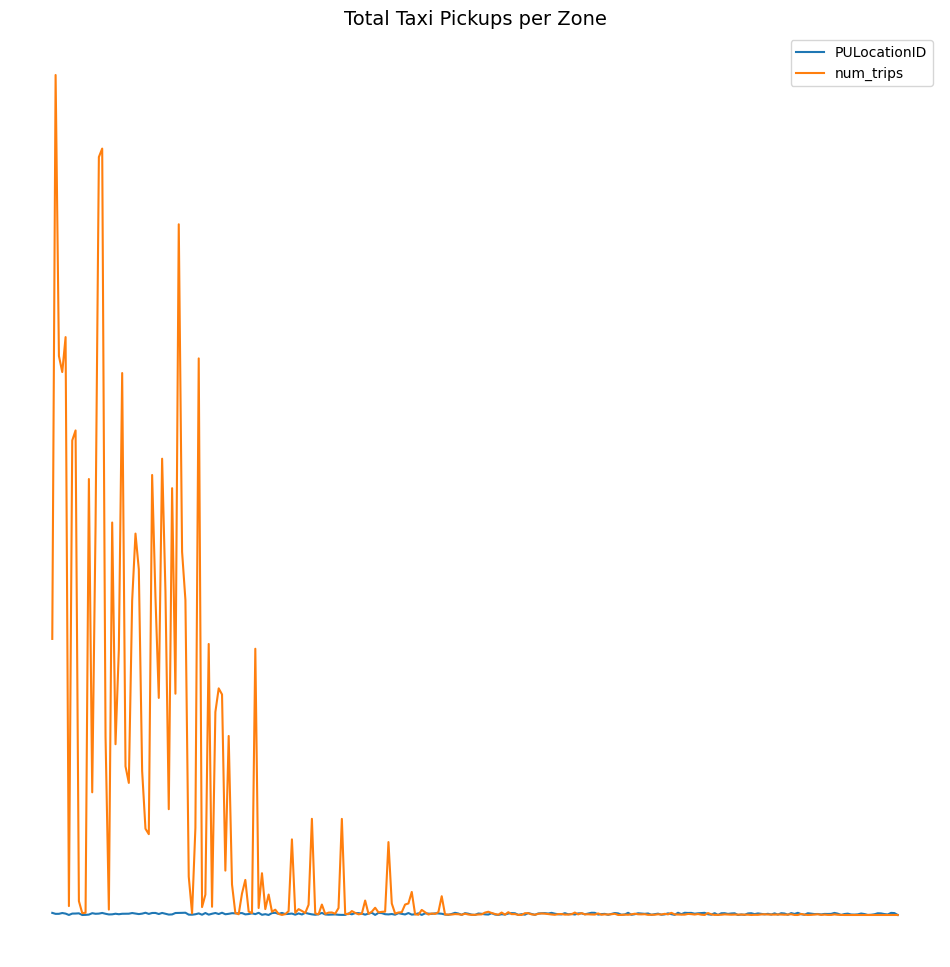

In [57]:
# Merge trip counts back to the zones GeoDataFrame

#group trips by pickup location (zone level)
zone_trip_counts = (
    trip_with_zones
    .groupby("PULocationID")
    .size()
    .reset_index(name="num_trips")
)

zone_trip_counts

#Create a zone GeoDataFrame (one polygon per zone)
zones_gdf = (
    trip_with_zones[
        ["PULocationID", "zone", "borough", "geometry"]
    ]
    .dropna(subset=["geometry"])                 # keep valid shapes
    .drop_duplicates(subset="PULocationID")      # one row per zone
)
zones_gdf

#Merge trip counts into the GeoDataFrame
zones_with_trips = zones_gdf.merge(
    zone_trip_counts,
    on="PULocationID",
    how="left"
)

zones_with_trips["num_trips"] = zones_with_trips["num_trips"].fillna(0)

#Sanity checks
zones_with_trips.shape
zones_with_trips["num_trips"].describe()
zones_with_trips.sort_values("num_trips", ascending=False).head(10)

#plot map - total trips per zone
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

zones_with_trips.plot(
    column="num_trips",
    legend=True,
    ax=ax
)

ax.set_title("Total Taxi Pickups per Zone", fontsize=14)
ax.axis("off")
plt.show()



The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

1.1.2


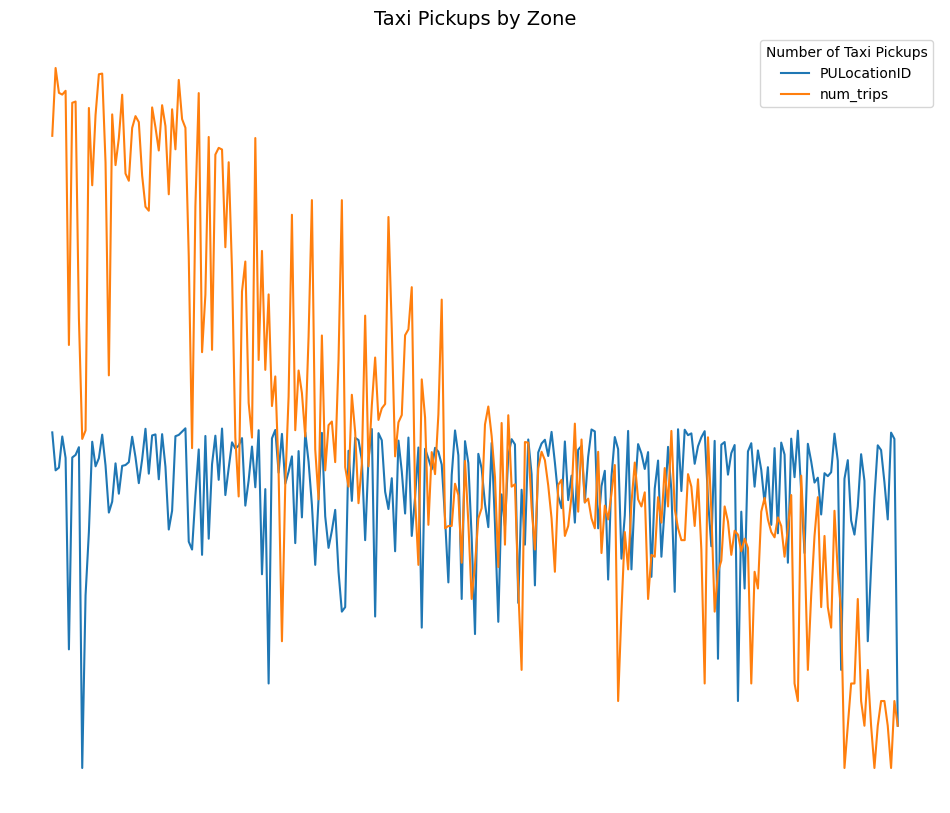

In [58]:
# Define figure and axis

import geopandas as gpd
print(gpd.__version__)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_trips.plot(
    column="num_trips",
    ax=ax,
    legend=True
)

# Manually set legend title
legend = ax.get_legend()
legend.set_title("Number of Taxi Pickups")
ax.set_yscale("log")


ax.set_title("Taxi Pickups by Zone", fontsize=14)
ax.axis("off")
plt.show()



In [59]:
# can you try displaying the zones DF sorted by the number of trips?

#sort zones by number of trips
zones_sorted = zones_with_trips.sort_values(
    by="num_trips",
    ascending=False
)

#Display key columns only (recommended)
zones_sorted[["borough", "zone", "num_trips"]].head(20)

#Display bottom zones (low-demand areas)
zones_sorted[["borough", "zone", "num_trips"]].tail(20)

#Reset index for clean presentation
zones_sorted = zones_sorted.reset_index(drop=True)
zones_sorted[["borough", "zone", "num_trips"]].head(20)

,borough,zone,num_trips
0,Queens,JFK Airport,97035
1,Manhattan,Upper East Side South,88536
2,Manhattan,Midtown Center,87557
3,Manhattan,Upper East Side North,79790
4,Manhattan,Midtown East,66759
5,Queens,LaGuardia Airport,64572
6,Manhattan,Penn Station/Madison Sq West,64297
7,Manhattan,Times Sq/Theatre District,62722
8,Manhattan,Lincoln Square East,62606
9,Manhattan,Murray Hill,55974


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [60]:
# Find routes which have the slowest speeds at different times of the day

#zones_gdf - zoned data
#trip_df - sampled trip data
#trip_with_zones - merged data > sampled trip + zone data

#Create trip duration (in hours)
# Trip duration in hours
trip_df['trip_duration_hours'] = (
    (trip_df['tpep_dropoff_datetime'] - trip_df['tpep_pickup_datetime'])
    .dt.total_seconds() / 3600
)

#print('trip duration hours',trip_df['trip_duration_hours'])

# Remove invalid durations
trip_df = trip_df[trip_df['trip_duration_hours'] > 0]

#Extract pickup hour
trip_df['pickup_hour'] = trip_df['tpep_pickup_datetime'].dt.hour

#print('pick up hour',trip_df['pickup_hour'])

#Define route (pickup → dropoff)
trip_df['route'] = (
    trip_df['PULocationID'].astype(str) + " → " +
    trip_df['DOLocationID'].astype(str)
)

#print('trip route',trip_df['route'])

#aggregate by route and hour

route_hour_stats = (
    trip_df
    .groupby(['route', 'pickup_hour'])
    .agg(
        avg_distance=('trip_distance', 'mean'),
        avg_duration=('trip_duration_hours', 'mean'),
        trip_count=('trip_distance', 'count')
    )
    .reset_index()
)
#route_hour_stats

#Calculate speed (miles/hour or km/hour)
route_hour_stats['avg_speed'] = (route_hour_stats['avg_distance'] / route_hour_stats['avg_duration'])

#Remove invalid speeds:

route_hour_stats = route_hour_stats.replace([np.inf, -np.inf], np.nan)
route_hour_stats = route_hour_stats.dropna(subset=['avg_speed'])

#Identify slowest routes per hour
slow_routes_by_hour = (
    route_hour_stats
    .sort_values(['pickup_hour', 'avg_speed'])
    .groupby('pickup_hour')
    .head(5)
)

#Display results
slow_routes_by_hour[
    ['pickup_hour', 'route', 'avg_speed', 'trip_count']
].sort_values(['pickup_hour', 'avg_speed'])

slow_routes_by_hour.describe()
#SUMMARY
#Several taxi zones exhibit severe micro-congestion where trips of near-zero distance take 30–60 minutes, 
#even during late-night hours—indicating bottlenecks that materially impact customer experience, driver earnings, and ETA reliability.”



,pickup_hour,avg_distance,avg_duration,trip_count,avg_speed
count,120.000000,120.0,120.000000,120.000000,120.0
mean,11.500000,0.0,0.495535,1.308333,0.0
std,6.951211,0.0,0.435842,0.994065,0.0
min,0.000000,0.0,0.000556,1.000000,0.0
25%,5.750000,0.0,0.052083,1.000000,0.0
50%,11.500000,0.0,0.439306,1.000000,0.0
75%,17.250000,0.0,0.760069,1.000000,0.0
max,23.000000,0.0,2.001389,7.000000,0.0


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Busiest hour: 18:00
Number of trips: 133896


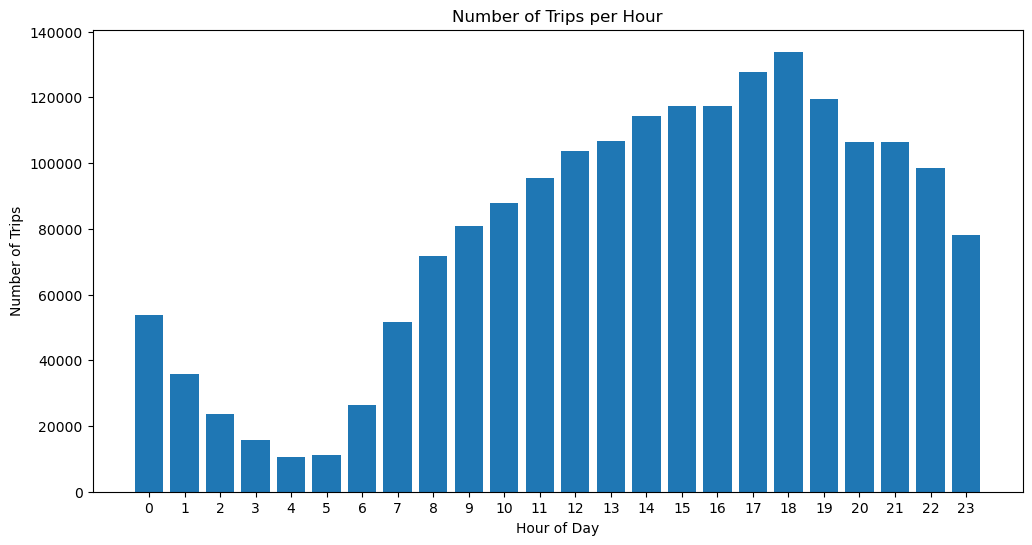

In [61]:
# Visualise the number of trips per hour and find the busiest hour

#Extract hour from pickup time
trip_df['pickup_hour'] = trip_df['tpep_pickup_datetime'].dt.hour

#Calculate number of trips per hour
trips_per_hour = (
    trip_df
    .groupby('pickup_hour')
    .size()
    .reset_index(name='num_trips')
)

#Identify the busiest hour
busiest_hour_row = trips_per_hour.loc[
    trips_per_hour['num_trips'].idxmax()
]

busiest_hour = busiest_hour_row['pickup_hour']
busiest_hour_trips = busiest_hour_row['num_trips']

print(f"Busiest hour: {busiest_hour}:00")
print(f"Number of trips: {busiest_hour_trips}")

#Visualise number of trips per hour
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(trips_per_hour['pickup_hour'], trips_per_hour['num_trips'])
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Number of Trips per Hour')
plt.xticks(range(0, 24))
plt.show()

#SUMMARY
#Taxi demand shows a strong and predictable daily pattern, peaking sharply at 6 PM with ~140K trips. 
#Demand remains high from noon to evening, indicating prime revenue hours, while early morning sees minimal activity. 
#These patterns support targeted driver incentives, dynamic pricing, and time-aware ETA models to maximize revenue and service quality.”

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [62]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.10

#Get trips per hour (from sampled data)

trips_per_hour = (
    trip_df
    .groupby('pickup_hour')
    .size()
    .reset_index(name='sampled_trips'))

#Identify the five busiest hours (sampled)
top_5_hours = trips_per_hour.sort_values(
    by='sampled_trips',
    ascending=False
).head(5)

#Scale up to get actual estimated trips
top_5_hours['estimated_actual_trips'] = (
    top_5_hours['sampled_trips'] / sample_fraction
)

#Display results clearly
top_5_hours.sort_values(
    by='estimated_actual_trips',
    ascending=False
)

#SUMMARY 
#After scaling for sampling, the busiest five hours collectively account for several million trips, 
#with peak demand at 6 PM alone exceeding one million trips—highlighting the critical importance of peak-hour capacity planning.

,pickup_hour,sampled_trips,estimated_actual_trips
18,18,133896,1338960.0
17,17,127820,1278200.0
19,19,119626,1196260.0
16,16,117455,1174550.0
15,15,117353,1173530.0


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

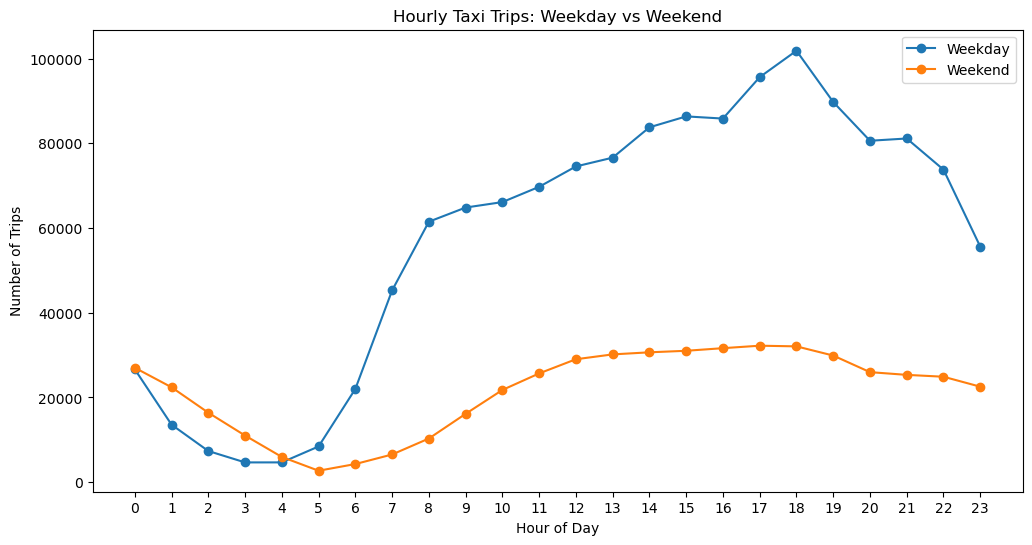

In [63]:
# Compare traffic trends for the week days and weekends

#Create weekday / weekend flag
# Day of week: Monday=0, Sunday=6
trip_df['day_of_week'] = trip_df['tpep_pickup_datetime'].dt.dayofweek

# Weekday vs Weekend
trip_df['day_type'] = trip_df['day_of_week'].apply(
    lambda x: 'Weekday' if x < 5 else 'Weekend'
)

# Pickup hour
trip_df['pickup_hour'] = trip_df['tpep_pickup_datetime'].dt.hour

#Calculate trips per hour for weekdays & weekends
hourly_daytype_trips = (
    trip_df
    .groupby(['day_type', 'pickup_hour'])
    .size()
    .reset_index(name='num_trips')
)

#print(hourly_daytype_trips)

#Split data for plotting
weekday_trips = hourly_daytype_trips[
    hourly_daytype_trips['day_type'] == 'Weekday'
]

weekend_trips = hourly_daytype_trips[
    hourly_daytype_trips['day_type'] == 'Weekend'
]

#Visualise: Weekday vs Weekend hourly pattern
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(
    weekday_trips['pickup_hour'],
    weekday_trips['num_trips'],
    label='Weekday',
    marker='o'
)

ax.plot(
    weekend_trips['pickup_hour'],
    weekend_trips['num_trips'],
    label='Weekend',
    marker='o'
)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Trips')
ax.set_title('Hourly Taxi Trips: Weekday vs Weekend')
ax.set_xticks(range(0, 24))
ax.legend()

plt.show()

#SUMMARY
#Weekday taxi demand is highly structured and commute-driven with sharp peaks, while weekend demand is leisure-driven, 
#flatter, and extends late into the night—requiring fundamentally different driver allocation, pricing, and ETA strategies.”

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [64]:
# Find top 10 pickup and dropoff zones

# Find top 10 pickup and dropoff zones
#Prepare Hour Columns

# Ensure datetime format
trip_with_zones['tpep_pickup_datetime'] = pd.to_datetime(
    trip_with_zones['tpep_pickup_datetime']
)
trip_with_zones['tpep_dropoff_datetime'] = pd.to_datetime(
    trip_with_zones['tpep_dropoff_datetime']
)

# Extract hour
trip_with_zones['pickup_hour'] = trip_with_zones['tpep_pickup_datetime'].dt.hour
trip_with_zones['dropoff_hour'] = trip_with_zones['tpep_dropoff_datetime'].dt.hour
                        
#Top 10 Zones with High Hourly Pickups
hourly_pickups = (
    trip_with_zones
    .groupby(['zone', 'pickup_hour'])
    .size()
    .reset_index(name='pickup_count')
)
# Total pickups per zone (across all hours)
top_10_pickup_zones = (
    hourly_pickups
    .groupby('zone')['pickup_count']
    .sum()
    .reset_index()
    .sort_values(by='pickup_count', ascending=False)
    .head(10)
)

top_10_pickup_zones

#Hourly Pickup Trends for Top 10 Pickup Zones
pickup_trends = (
    hourly_pickups
    .merge(top_10_pickup_zones[['zone']], on='zone')
    .sort_values(['zone', 'pickup_hour'])
)

pickup_trends.head()

#Top 10 Zones with High Hourly Drop-offs
hourly_dropoffs = (
    trip_with_zones
    .groupby(['zone', 'dropoff_hour'])
    .size()
    .reset_index(name='dropoff_count')
)

# Total dropoffs per zone
top_10_dropoff_zones = (
    hourly_dropoffs
    .groupby('zone')['dropoff_count']
    .sum()
    .reset_index()
    .sort_values(by='dropoff_count', ascending=False)
    .head(10)
)

top_10_dropoff_zones

#Hourly Drop-off Trends for Top 10 Drop-off Zones
dropoff_trends = (
    hourly_dropoffs
    .merge(top_10_dropoff_zones[['zone']], on='zone')
    .sort_values(['zone', 'dropoff_hour'])
)

dropoff_trends.head()

#Pickup Trend Pivot
pickup_pivot = pickup_trends.pivot(
    index='pickup_hour',
    columns='zone',
    values='pickup_count'
)

pickup_pivot

#Drop-off Trend Pivot
dropoff_pivot = dropoff_trends.pivot(
    index='dropoff_hour',
    columns='zone',
    values='dropoff_count'
)

dropoff_pivot

top_10_pickup_zones
top_10_dropoff_zones


,zone,dropoff_count
119,JFK Airport,97035
228,Upper East Side South,88536
152,Midtown Center,87557
227,Upper East Side North,79790
153,Midtown East,66759
129,LaGuardia Airport,64572
177,Penn Station/Madison Sq West,64297
221,Times Sq/Theatre District,62722
133,Lincoln Square East,62606
161,Murray Hill,55974


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [65]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

#Pickup counts per zone
pickup_counts = (
    trip_with_zones
    .groupby(['PULocationID', 'zone'])
    .size()
    .reset_index(name='pickup_count')
)

#Drop-off counts per zone
dropoff_counts = (
    trip_with_zones
    .groupby(['DOLocationID', 'zone'])
    .size()
    .reset_index(name='dropoff_count')
)

#Standardize zone column before merge (Since pickup and drop-off IDs differ)

pickup_counts = pickup_counts.rename(columns={'PULocationID': 'LocationID'})
dropoff_counts = dropoff_counts.rename(columns={'DOLocationID': 'LocationID'})

#Merge pickup & drop-off counts
zone_ratios = pickup_counts.merge(
    dropoff_counts,
    on=['LocationID', 'zone'],
    how='outer'
).fillna(0)

#Calculate Pickup / Drop-off Ratio
zone_ratios['pickup_drop_ratio'] = (
    zone_ratios['pickup_count'] /
    zone_ratios['dropoff_count'].replace(0, np.nan)
)

#Top 10 Zones with Highest Pickup / Drop-off Ratio

top_10_high_ratio = (
    zone_ratios
    .dropna(subset=['pickup_drop_ratio'])
    .sort_values(by='pickup_drop_ratio', ascending=False)
    .head(10)
)

print('10 highest (pickup/drop) ratios.',top_10_high_ratio)

#Top 10 Zones with Lowest Pickup / Drop-off Ratio
top_10_low_ratio = (
    zone_ratios
    .dropna(subset=['pickup_drop_ratio'])
    .sort_values(by='pickup_drop_ratio', ascending=True)
    .head(10)
)

print('10 lowest (pickup/drop)',top_10_low_ratio)

#SUMMARY
#Zones with high pickup/drop-off ratios represent major transit and commercial hubs where taxi demand is outbound-heavy,
#while low-ratio zones are primarily residential or restricted areas acting as trip termination points, highlighting strong 
#directional mobility patterns and the need for strategic fleet rebalancing.


10 highest (pickup/drop) ratios.        LocationID                            zone  pickup_count  \
606            12                    Battery Park         840.0   
14299         186    Penn Station/Madison Sq West       64297.0   
10313         138               LaGuardia Airport       64572.0   
9063          125                       Hudson Sq        9337.0   
1423           24                    Bloomingdale        4827.0   
6664           88        Financial District South        5129.0   
20321         261              World Trade Center        9965.0   
1929           32                       Bronxdale          56.0   
16821         224  Stuy Town/Peter Cooper Village        2484.0   
15780         209                         Seaport        3526.0   

       dropoff_count  pickup_drop_ratio  
606              7.0         120.000000  
14299          856.0          75.113318  
10313          927.0          69.656958  
9063           135.0          69.162963  
1423            78.

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [66]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

#Filter Night-Hour Trips
night_hours = [23, 0, 1, 2, 3, 4, 5]

night_trips = trip_with_zones[
    trip_with_zones['pickup_hour'].isin(night_hours)
]

#Top 10 Night Pickup Zones
night_pickups = (
    night_trips
    .groupby(['PULocationID', 'zone'])
    .size()
    .reset_index(name='night_pickup_count')
    .sort_values(by='night_pickup_count', ascending=False)
    .head(10)
)

print('Top 10 Night Pickup Zones',night_pickups)

#Top 10 Night Drop-off Zones
night_dropoffs = (
    night_trips
    .groupby(['DOLocationID', 'zone'])
    .size()
    .reset_index(name='night_dropoff_count')
    .sort_values(by='night_dropoff_count', ascending=False)
    .head(10)
)

print('Top 10 Night drop off Zones',night_dropoffs)

#SUMMARY
#Night-time taxi demand in NYC is highly concentrated around nightlife districts, transit hubs, and airports, 
#with pickups dominated by entertainment areas and drop-offs skewed toward nearby residential neighborhoods. 
#The strong spatial overlap indicates short, localized trips driven by safety, convenience, and limited public transport availability


Top 10 Night Pickup Zones      PULocationID                          zone  night_pickup_count
71             79                  East Village               16452
116           132                   JFK Airport               14594
226           249                  West Village               13126
42             48                  Clinton East               10868
132           148               Lower East Side               10194
100           114       Greenwich Village South                9170
208           230     Times Sq/Theatre District                8505
167           186  Penn Station/Madison Sq West                7127
147           164                 Midtown South                6482
60             68                  East Chelsea                6382
Top 10 Night drop off Zones        DOLocationID             zone  night_dropoff_count
2858             79     East Village                  900
2916             79     West Village                  857
3901            107     

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [67]:
# Filter for night hours (11 PM to 5 AM)

#Create Time Category Column
night_hours = [23, 0, 1, 2, 3, 4, 5]

trip_with_zones['time_period'] = trip_with_zones['pickup_hour'].apply(
    lambda x: 'Nighttime' if x in night_hours else 'Daytime'
)

trip_with_zones['time_period']

#Calculate Revenue by Time Period - (Using total_amount as trip revenue)
revenue_by_time = (
    trip_with_zones
    .groupby('time_period')['total_amount']
    .sum()
    .reset_index(name='total_revenue')
)

#Calculate Revenue Share (%)
total_revenue = revenue_by_time['total_revenue'].sum()

revenue_by_time['revenue_share_pct'] = (
    revenue_by_time['total_revenue'] / total_revenue * 100
)

revenue_by_time

#SUMMARY
#Although daytime hours contribute nearly 88% of total taxi revenue due to high trip volumes, 
#nighttime hours generate only about 12% despite spanning almost one-third of the day. 
#This highlights an opportunity to optimize nighttime pricing, as demand during these hours is more inelastic and operationally costly

,time_period,total_revenue,revenue_share_pct
0,Daytime,48208317.22,87.697891
1,Nighttime,6762579.83,12.302109


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [68]:
# Analyse the fare per mile per passenger for different passenger counts
#Filter Valid Trips - (Remove zero distance & zero passengers to avoid invalid math)

valid_trips = trip_with_zones[
    (trip_with_zones['trip_distance'] > 0) &
    (trip_with_zones['passenger_count'] > 0)
]

#  print('Valid Trips are: ',valid_trips)

#Calculate Fare per Mile
valid_trips['fare_per_mile'] = (
    valid_trips['fare_amount'] / valid_trips['trip_distance']
)

#print('Valid Trips per mile are: ',valid_trips['fare_per_mile'])

#Average Fare per Mile by Passenger Count
avg_fare_per_mile = (
    valid_trips
    .groupby('passenger_count')['fare_per_mile']
    .mean()
    .reset_index(name='avg_fare_per_mile')
)

#print('Average Fare Per Mile: ',avg_fare_per_mile)

#Fare per Mile per Passenger
avg_fare_per_mile['fare_per_mile_per_passenger'] = (
    avg_fare_per_mile['avg_fare_per_mile'] /
    avg_fare_per_mile['passenger_count']
)

print('Average Fare per Mile per Passenger: ',avg_fare_per_mile)

#SUMMARY
#The fare per mile per passenger decreases sharply as passenger count increases, 
#demonstrating strong economies of scale in taxi pricing. Single-passenger trips are the least cost-efficient,
#while shared trips with 3–6 passengers offer the best value. Extremely high values for passenger counts above 7 
#indicate data anomalies and should be excluded from pricing decisions



Average Fare per Mile per Passenger:     passenger_count  avg_fare_per_mile  fare_per_mile_per_passenger
0              1.0          11.032252                    11.032252
1              2.0          12.969509                     6.484754
2              3.0          11.847186                     3.949062
3              4.0          17.932043                     4.483011
4              5.0           8.596204                     1.719241
5              6.0           8.095567                     1.349261
6              7.0           9.161844                     1.308835
7              8.0         229.018132                    28.627266
8              9.0         684.882016                    76.098002


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [69]:
# Compare the average fare per mile for different days and for different times of the day

#Prepare Data (Filter Valid Trips)
valid_trips = trip_with_zones[
    (trip_with_zones['trip_distance'] > 0)
].copy()

valid_trips

#Create Fare per Mile Column
valid_trips['fare_per_mile'] = (
    valid_trips['fare_amount'] / valid_trips['trip_distance']
)

valid_trips

#Extract Day of Week (0 = Monday, 6 = Sunday)

valid_trips['day_of_week'] = (
    valid_trips['tpep_pickup_datetime'].dt.day_name()
)

valid_trips['day_of_week'] 

#Average Fare per Mile by Hour of Day
avg_fare_per_mile_by_hour = (
    valid_trips
    .groupby('pickup_hour')['fare_per_mile']
    .mean()
    .reset_index(name='avg_fare_per_mile')
    .sort_values('pickup_hour')
)

avg_fare_per_mile_by_hour

#Average Fare per Mile by Day of Week
avg_fare_per_mile_by_day = (
    valid_trips
    .groupby('day_of_week')['fare_per_mile']
    .mean()
    .reset_index(name='avg_fare_per_mile')
)

# Optional: Order days correctly
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

avg_fare_per_mile_by_day['day_of_week'] = pd.Categorical(
    avg_fare_per_mile_by_day['day_of_week'],
    categories=day_order,
    ordered=True
)

avg_fare_per_mile_by_day.sort_values('day_of_week')

#SUMMARY
#Average fare per mile varies significantly across days of the week, with Sunday and Tuesday exhibiting the highest
#fare efficiency due to longer trips and lower congestion, while Saturday and Friday show lower fare per mile driven by short,
#localized leisure travel and traffic congestion.


,day_of_week,avg_fare_per_mile
1,Monday,10.947058
5,Tuesday,12.127373
6,Wednesday,11.042996
4,Thursday,11.142691
0,Friday,10.936810
2,Saturday,10.856273
3,Sunday,12.597154


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [70]:
# Compare fare per mile for different vendors

#Prepare Data (filter valid trips)
valid_trips = trip_with_zones[
    (trip_with_zones['trip_distance'] > 0)
].copy()

# Calculate fare per mile
valid_trips['fare_per_mile'] = valid_trips['fare_amount'] / valid_trips['trip_distance']

#Average Fare per Mile by Vendor and Hour
avg_fare_vendor_hour = (
    valid_trips
    .groupby(['VendorID', 'pickup_hour'])['fare_per_mile']
    .mean()
    .reset_index(name='avg_fare_per_mile')
    .sort_values(['VendorID', 'pickup_hour'])
)

avg_fare_vendor_hour

#Pivot for Easier Comparison
pivot_vendor_hour = avg_fare_vendor_hour.pivot(
    index='pickup_hour',
    columns='VendorID',
    values='avg_fare_per_mile'
)

pivot_vendor_hour

#SUMMARY
#Fare per mile varies significantly by vendor and hour. Vendor 2 consistently earns higher fares, 
#especially during late-night and early morning hours, reflecting high-value trips such as airport and long-distance rides. 
#Vendor 1 maintains stable fares suitable for high-volume daytime trips. Vendor 6 shows extreme outliers that should be cleaned.
#These patterns suggest a vendor- and time-specific pricing strategy to optimize revenue while managing operational efficiency.


VendorID,1,2,6
pickup_hour,,,
0,6.787147,11.493706,4.363383
1,7.046146,12.437853,5.728431
2,6.923390,10.740743,NaN
3,6.502725,12.512352,NaN
4,7.497771,14.930425,55.510204
5,6.962445,16.530040,3.889734
6,6.641411,12.916760,3.892467
7,7.192124,11.376297,4.238542
8,8.071441,11.171685,5.220734


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [71]:
# Defining distance tiers

#Prepare Data (filter valid trips)
valid_trips = trip_with_zones[
    (trip_with_zones['trip_distance'] > 0)
].copy()

# Fare per mile
valid_trips['fare_per_mile'] = valid_trips['fare_amount'] / valid_trips['trip_distance']

#Create Distance Tier Column
def distance_tier(distance):
    if distance <= 2:
        return '0-2 miles'
    elif distance <= 5:
        return '2-5 miles'
    else:
        return '>5 miles'

valid_trips['distance_tier'] = valid_trips['trip_distance'].apply(distance_tier)
valid_trips['distance_tier']

#Average Fare per Mile by Vendor and Distance Tier
avg_fare_vendor_distance = (
    valid_trips
    .groupby(['VendorID', 'distance_tier'])['fare_per_mile']
    .mean()
    .reset_index(name='avg_fare_per_mile')
    .sort_values(['VendorID', 'distance_tier'])
)

avg_fare_vendor_distance

#Pivot for Comparison
pivot_vendor_distance = avg_fare_vendor_distance.pivot(
    index='distance_tier',
    columns='VendorID',
    values='avg_fare_per_mile'
)

pivot_vendor_distance

#SUMMARY
#Fare per mile decreases with increasing trip distance for all vendors. Short trips (0–2 miles) are the most expensive per mile due
#to congestion and minimum fares, with Vendor 2 consistently commanding a premium and Vendor 6 showing extreme outliers. 
#Medium trips (2–5 miles) provide moderate fare efficiency, while long trips (>5 miles) benefit from economies of scale, 
#reducing fare per mile. These results support a tiered pricing strategy and a vendor-specific operational allocation to maximize 
#revenue and efficiency

VendorID,1,2,6
distance_tier,,,
0-2 miles,10.628389,18.032410,24.746308
2-5 miles,6.379898,6.537595,8.196262
>5 miles,4.424796,4.489702,4.375823


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [72]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

#Prepare Data - Filter valid trips
valid_trips = trip_with_zones[
    (trip_with_zones['fare_amount'] > 0)
].copy()

# Calculate tip percentage
valid_trips['tip_pct'] = (valid_trips['tip_amount'] / valid_trips['fare_amount']) * 100

#Tip Percentage by Distance Tier
# Distance tiers
def distance_tier(distance):
    if distance <= 2:
        return '0-2 miles'
    elif distance <= 5:
        return '2-5 miles'
    else:
        return '>5 miles'

valid_trips['distance_tier'] = valid_trips['trip_distance'].apply(distance_tier)

avg_tip_by_distance = (
    valid_trips.groupby('distance_tier')['tip_pct']
    .mean()
    .reset_index(name='avg_tip_pct')
)

avg_tip_by_distance

#Tip Percentage by Passenger Count
avg_tip_by_passenger = (
    valid_trips.groupby('passenger_count')['tip_pct']
    .mean()
    .reset_index(name='avg_tip_pct')
    .sort_values('passenger_count')
)

avg_tip_by_passenger

#Tip Percentage by Pickup Hour
avg_tip_by_hour = (
    valid_trips.groupby('pickup_hour')['tip_pct']
    .mean()
    .reset_index(name='avg_tip_pct')
    .sort_values('pickup_hour')
)

print('Avg trip by hour', avg_tip_by_hour)
print('Avg trip by Distance',avg_tip_by_distance)
print('Avg trip by passenger',avg_tip_by_passenger)

#Tip behavior varies significantly by time, distance, and passenger composition.
#Late-night, short-distance, solo-passenger trips generate the highest tip percentages, 
#while long-distance and large-group trips show consistently lower tipping behavior.

Avg trip by hour     pickup_hour  avg_tip_pct
0             0    25.858222
1             1    20.675158
2             2    20.175662
3             3    19.922696
4             4    18.283998
5             5    17.147929
6             6    17.949500
7             7    19.255497
8             8    19.681046
9             9    19.539514
10           10    19.178760
11           11    19.085646
12           12    19.090900
13           13    19.841528
14           14    20.729213
15           15    24.934021
16           16    20.731851
17           17    24.066187
18           18    21.933159
19           19    22.012010
20           20    21.243928
21           21    21.328423
22           22    20.894248
23           23    23.496547
Avg trip by Distance   distance_tier  avg_tip_pct
0     0-2 miles    23.567708
1     2-5 miles    18.635014
2      >5 miles    17.530190
Avg trip by passenger    passenger_count  avg_tip_pct
0              0.0    19.871714
1              1.0    21.998363
2  

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [73]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

#Prepare Data
# Filter valid trips
tip_analysis = trip_with_zones[
    (trip_with_zones['fare_amount'] > 0)
].copy()

# Tip percentage
tip_analysis['tip_pct'] = (tip_analysis['tip_amount'] / tip_analysis['fare_amount']) * 100

# Create low-tip and high-tip categories
tip_analysis['tip_category'] = tip_analysis['tip_pct'].apply(
    lambda x: 'Low Tip (<10%)' if x < 10 else ('High Tip (>25%)' if x > 25 else 'Medium Tip')
)

#Compare Trip Distance
avg_distance_by_tip = tip_analysis.groupby('tip_category')['trip_distance'].mean()
avg_distance_by_tip

#Compare Passenger Count
avg_passenger_by_tip = tip_analysis.groupby('tip_category')['passenger_count'].mean()
avg_passenger_by_tip

#Compare Pickup Hour
avg_hour_by_tip = tip_analysis.groupby('tip_category')['pickup_hour'].mean()
avg_hour_by_tip

tip_category
High Tip (>25%)    14.590448
Low Tip (<10%)     13.893043
Medium Tip         14.124290
Name: pickup_hour, dtype: float64

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [74]:
# See how passenger count varies across hours and days

#Prepare Data
# Ensure passenger count is valid
valid_trips = trip_with_zones[trip_with_zones['passenger_count'] > 0].copy()

# Extract day of week
valid_trips['day_of_week'] = valid_trips['tpep_pickup_datetime'].dt.day_name()

#Average Passenger Count by Hour
avg_passenger_by_hour = (
    valid_trips.groupby('pickup_hour')['passenger_count']
    .mean()
    .reset_index(name='avg_passenger_count')
    .sort_values('pickup_hour')
)

avg_passenger_by_hour

#Average Passenger Count by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

avg_passenger_by_day = (
    valid_trips.groupby('day_of_week')['passenger_count']
    .mean()
    .reset_index(name='avg_passenger_count')
)

avg_passenger_by_day['day_of_week'] = pd.Categorical(
    avg_passenger_by_day['day_of_week'],
    categories=day_order,
    ordered=True
)

avg_passenger_by_day.sort_values('day_of_week')


#Heatmap of Passenger Count by Hour and Day
pivot_hour_day = valid_trips.pivot_table(
    index='pickup_hour',
    columns='day_of_week',
    values='passenger_count',
    aggfunc='mean'
)

pivot_hour_day

day_of_week,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
pickup_hour,,,,,,,
0,1.393220,1.401743,1.470128,1.503389,1.358852,1.403974,1.358941
1,1.379736,1.441283,1.468602,1.483895,1.369013,1.368821,1.327116
2,1.400154,1.378744,1.488581,1.479607,1.396552,1.434194,1.355597
3,1.416447,1.499301,1.465708,1.479533,1.381319,1.488235,1.436950
4,1.325312,1.444444,1.431453,1.450322,1.340855,1.320624,1.356223
5,1.303765,1.292361,1.325987,1.406740,1.263124,1.306694,1.230311
6,1.265268,1.270483,1.313686,1.353095,1.238642,1.221020,1.238571
7,1.288059,1.276214,1.321115,1.369372,1.264340,1.267903,1.265717
8,1.309517,1.297137,1.371166,1.400045,1.278014,1.274264,1.272281


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [75]:
# How does passenger count vary across zones
# Ensure valid trips
valid_trips = trip_with_zones[trip_with_zones['passenger_count'] > 0].copy()

# Average passenger count by pickup zone
avg_passenger_by_zone = (
    valid_trips.groupby(['PULocationID', 'zone'])['passenger_count']
    .mean()
    .reset_index(name='avg_passenger_count')
    .sort_values('avg_passenger_count', ascending=False)
)

# Top 10 zones by avg passengers
top10_zones = avg_passenger_by_zone.head(10)

# Bottom 10 zones by avg passengers
bottom10_zones = avg_passenger_by_zone.tail(10)

print('Top 10 zones by avg passengers',top10_zones)
print('Bottom 10 zones by avg passengers',bottom10_zones)

Top 10 zones by avg passengers      PULocationID                     zone  avg_passenger_count
103           111      Green-Wood Cemetery             2.000000
5               6  Arrochar/Fort Wadsworth             1.875000
186           195                 Red Hook             1.818653
195           204        Rossville/Woodrow             1.800000
11             12             Battery Park             1.763387
55             58             Country Club             1.666667
169           178      Ocean Parkway South             1.615385
0               1           Newark Airport             1.603774
63             66       DUMBO/Vinegar Hill             1.583691
251           261       World Trade Center             1.551516
Bottom 10 zones by avg passengers      PULocationID                       zone  avg_passenger_count
164           172     New Dorp/Midland Beach                  1.0
148           156            Mariners Harbor                  1.0
175           184            Pelh

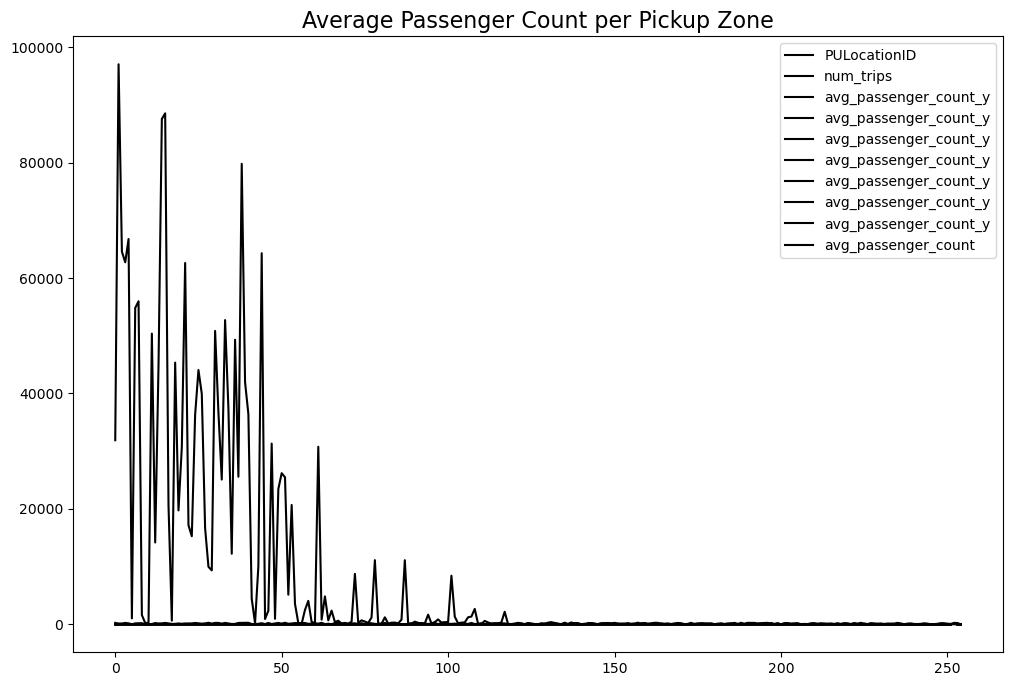

In [99]:

#For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

#Calculate Average Passenger Count per Zone
# Assuming 'zones_with_trips' has 'LocationID' as zone identifier
# and trip data has 'PULocationID' and 'passenger_count'

# Group by pickup zone and calculate average passengers
avg_passenger_per_zone = trip_with_zones.groupby('PULocationID')['passenger_count'] \
    .mean().reset_index(name='avg_passenger_count')

zones_with_trips = zones_with_trips.drop(columns=['avg_passenger_count_x'], errors='ignore')


# Merge with zones GeoDataFrame
zones_with_trips = zones_with_trips.merge(
    avg_passenger_per_zone,
    left_on='PULocationID',
    right_on='PULocationID',
    how='left'
)

#Check the Data
#zones_with_trips[['PULocationID', 'zone', 'avg_passenger_count']].head(10)
#zones_with_trips['avg_passenger_count'] = zones_with_trips['avg_passenger_count'].fillna(0)

zones_with_trips.columns

#Visualization (Choropleth Map)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
zones_with_trips.plot(
    column='avg_passenger_count_y',
    ax=ax,
    legend=True,
    cmap='YlGnBu',
    color='black'
)
ax.set_title('Average Passenger Count per Pickup Zone', fontsize=16)
plt.show()



In [98]:
avg_passenger_per_zone
zones_with_trips

,PULocationID,zone,borough,geometry,num_trips,avg_passenger_count_y,avg_passenger_count_y,avg_passenger_count_y,avg_passenger_count_y,avg_passenger_count_y,avg_passenger_count_y,avg_passenger_count_x,avg_passenger_count_y
0,246,West Chelsea/Hudson Yards,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216...",31893,1.421377,1.421377,1.421377,1.421377,1.421377,1.421377,1.421377,1.421377
1,132,JFK Airport,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",97035,1.489079,1.489079,1.489079,1.489079,1.489079,1.489079,1.489079,1.489079
2,138,LaGuardia Airport,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031...",64572,1.355343,1.355343,1.355343,1.355343,1.355343,1.355343,1.355343,1.355343
3,230,Times Sq/Theatre District,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21...",62722,1.479644,1.479644,1.479644,1.479644,1.479644,1.479644,1.479644,1.479644
4,162,Midtown East,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",66759,1.319457,1.319457,1.319457,1.319457,1.319457,1.319457,1.319457,1.319457
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,109,Great Kills,Staten Island,"POLYGON ((943392.585 147162.426, 943412.636 14...",3,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
251,59,Crotona Park,Bronx,"POLYGON ((1014848.343 245121.005, 1015049.583 ...",2,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000
252,245,West Brighton,Staten Island,"POLYGON ((957085.564 172591.26, 957142.385 172...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
253,221,Stapleton,Staten Island,"POLYGON ((963349.728 171627.581, 963397.759 17...",3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [100]:
# How often is each surcharge applied?

# List of surcharge columns
surcharge_cols = [
    'extra', 
    'mta_tax', 
    'tolls_amount', 
    'improvement_surcharge', 
    'congestion_surcharge', 
    'airport_fee'
]

# Count how many trips have surcharge > 0
surcharge_counts = {}
for col in surcharge_cols:
    surcharge_counts[col] = (trip_with_zones[col] > 0).sum()

# Convert to DataFrame
surcharge_counts_df = pd.DataFrame.from_dict(
    surcharge_counts, orient='index', columns=['trip_count']
).sort_values(by='trip_count', ascending=False)

# Add percentage of trips
total_trips = len(trip_with_zones)
surcharge_counts_df['pct_of_trips'] = (surcharge_counts_df['trip_count'] / total_trips) * 100

surcharge_counts_df

#SUMMARY
#Surcharges are applied with varying frequency in NYC taxi trips. The improvement surcharge and MTA tax are nearly universal,
#while congestion surcharges affect a large majority of trips. Moderate-frequency surcharges like ‘extra’ apply to about 60% of trips. 
#Low-frequency surcharges, such as tolls (8%) and airport fees (0.68%), are infrequent but high-margin. Understanding surcharge frequency 
#helps in revenue forecasting, fleet allocation, and pricing strategy optimization


,trip_count,pct_of_trips
improvement_surcharge,1895597,99.947801
mta_tax,1878690,99.056358
congestion_surcharge,1690578,89.137909
extra,1139685,60.091364
tolls_amount,153779,8.108196
airport_fee,12957,0.683175


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
#added in report file

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
#added in report file

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [ ]:
#added in report file